In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import tensorflow_decision_forests as tfdf
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, root_mean_squared_error, roc_curve, auc
import seaborn as sns
import kagglehub
from datetime import datetime

2025-12-08 12:20:53.658312: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-08 12:20:54.079082: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765225254.212001     866 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765225254.252184     866 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1765225254.579743     866 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

/mnt/c/Users/flope/Documents/CSE176ML/CSE176MLProject/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Classification with Tensorflow Decision Forest

## Download and store data into a dataframe 

In [3]:
# Download latest version
path = kagglehub.dataset_download("eshummalik/securepay-credit-card-fraud-detection-data")

print("Path to dataset files:", path)

Path to dataset files: /home/flopez0294/.cache/kagglehub/datasets/eshummalik/securepay-credit-card-fraud-detection-data/versions/1


In [4]:
df = pd.read_csv(os.path.join(path, 'creditcard.csv'))

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
dfSize = np.shape(df)
print(dfSize)
n = dfSize[0]
col = dfSize[1]

(284807, 31)


## Preproccessing

In [6]:
# check for NA values
print(df.isna().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [7]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


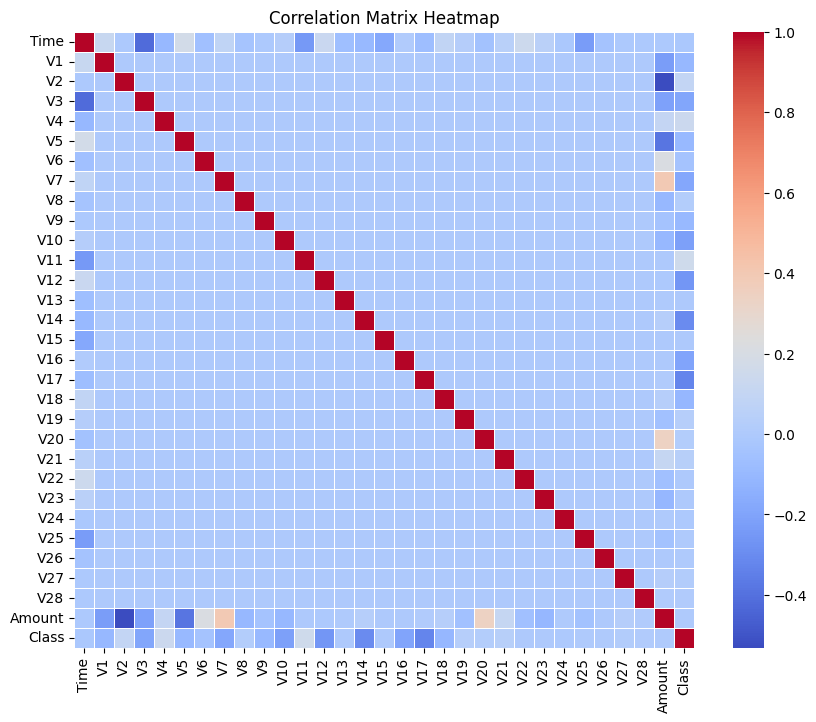

In [8]:
correlation_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=.5, )
plt.title('Correlation Matrix Heatmap')
plt.show()

['Amount', 'V28', 'V27', 'V26', 'V25', 'V24', 'V23', 'V22', 'V21', 'V20', 'V19', 'V18', 'V17', 'V16', 'V15', 'V14', 'V13', 'V12', 'V11', 'V10', 'V9', 'V8', 'V7', 'V6', 'V5', 'V4', 'V3', 'V2', 'V1', 'Time']


/tmp/ipykernel_866/3089307564.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[idx, jdx].boxplot([fea_class0, fea_class1], labels=['Not Fraud', 'Fraud'])
/tmp/ipykernel_866/3089307564.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[idx, jdx].boxplot([fea_class0, fea_class1], labels=['Not Fraud', 'Fraud'])
/tmp/ipykernel_866/3089307564.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[idx, jdx].boxplot([fea_class0, fea_class1], labels=['Not Fraud', 'Fraud'])
/tmp/ipykernel_866/3089307564.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since

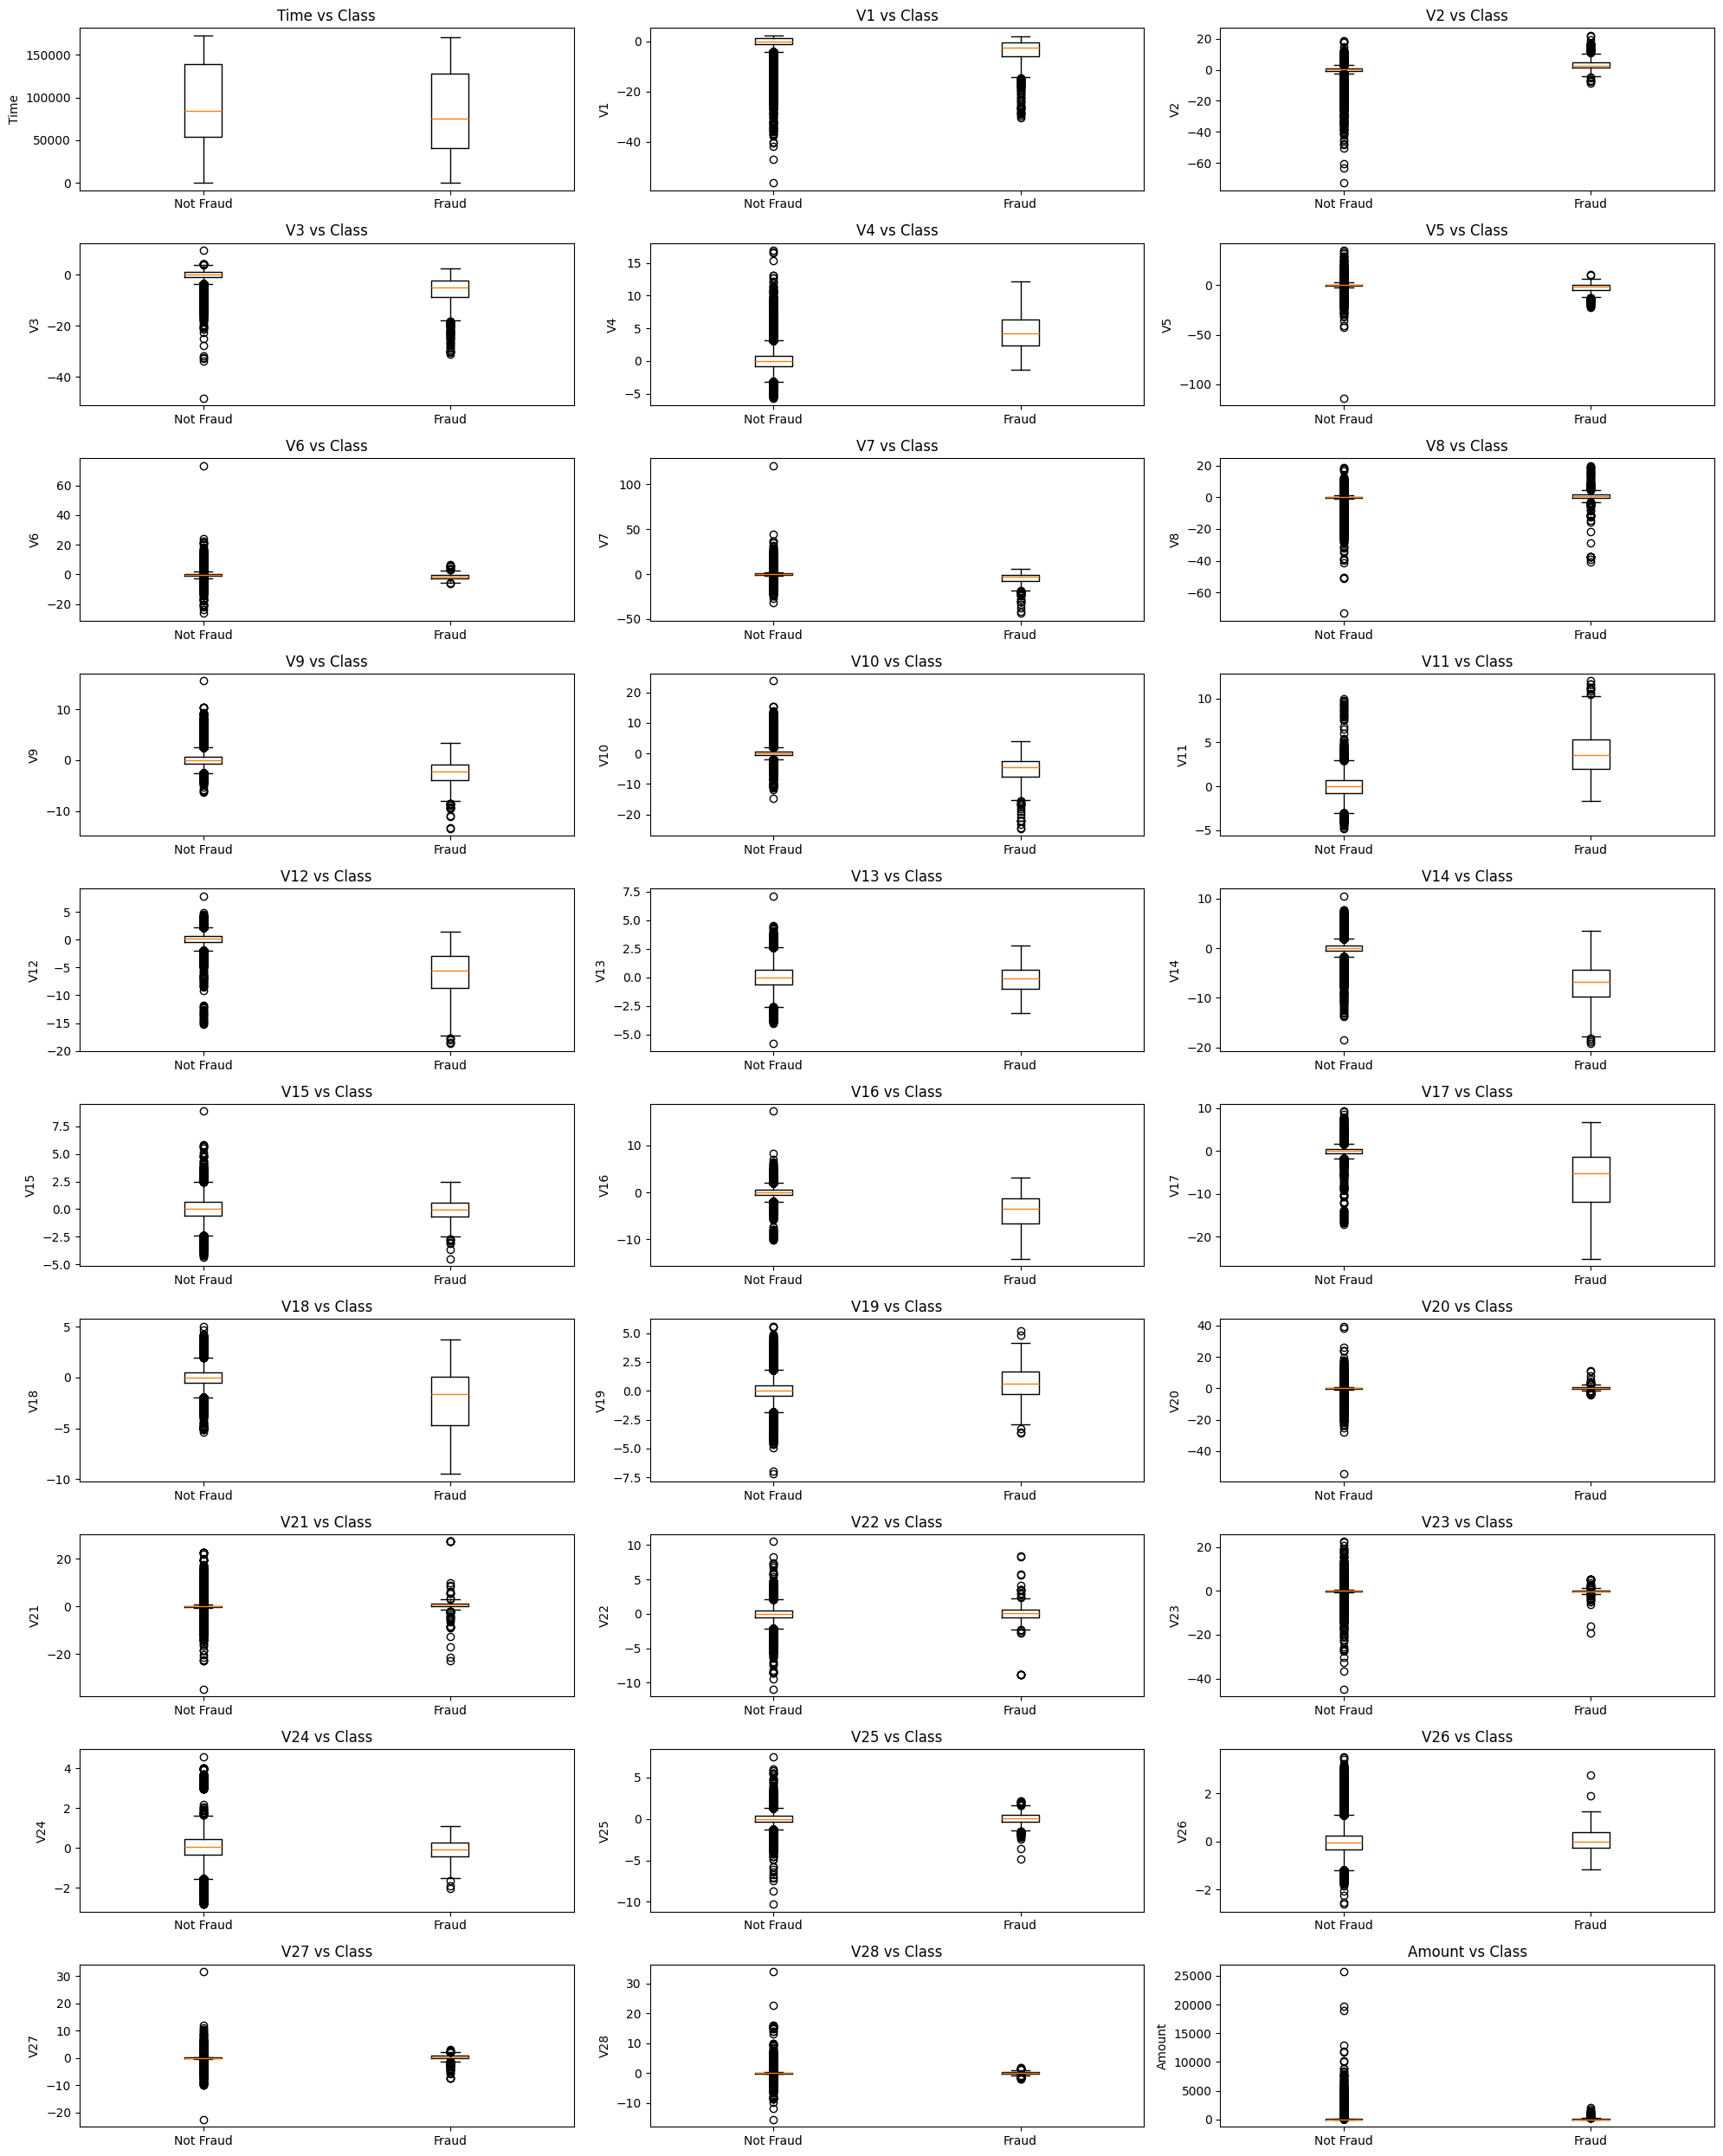

In [ ]:
features = list(df.columns.drop('Class'))[::-1]
print(features)
fig, axs = plt.subplots(10, 3, figsize=(20,25))

for idx, ax in enumerate(axs):
    # Create two groups: V17 for class 0 and class 1
    for jdx, jx in enumerate(ax):
        fea = features.pop()
        fea_class0 = df[df['Class'] == 0][fea]
        fea_class1 = df[df['Class'] == 1][fea]
        axs[idx, jdx].boxplot([fea_class0, fea_class1], labels=['Not Fraud', 'Fraud'])
        axs[idx, jdx].set_ylabel(fea)
        axs[idx, jdx].set_title(f'{fea} vs Class')

plt.tight_layout()
plt.show()

'V12', 'V17', 'V4', 'V14', 'V10', 'V6', 'Time' - RandomForest best forward 7

'V14', 'V12', 'V4', 'V22', 'V1', 'V16', 'V3' - logistic Regression best forward 7

Notice from the graphs that the fraud class data is more likely to be compacted then the Not Fraud class
- Time doesn't seem to matter since they basically have the same spread for both classes
- seems like The amound spent is relatively small for the Fraud class when compared to the Not Fraud.

0         green
1         green
2         green
3         green
4         green
          ...  
284802    green
284803    green
284804    green
284805    green
284806    green
Name: Class, Length: 284807, dtype: object


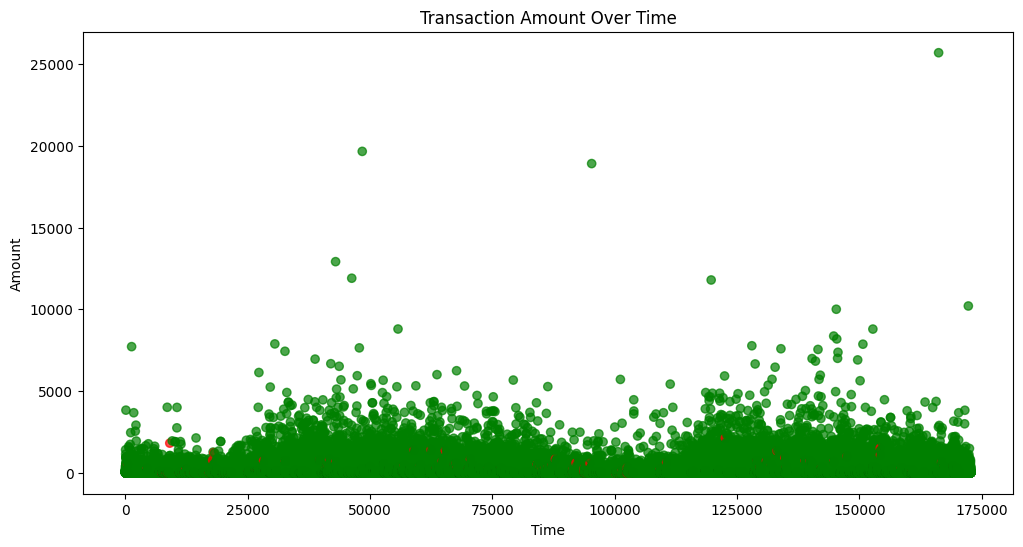

In [10]:
plt.figure(figsize=(12,6))
colors = df['Class'].map({0:'green', 1:'red'})
print(colors)
plt.scatter(df["Time"], df["Amount"], alpha=0.7, c=colors)
plt.title("Transaction Amount Over Time")
plt.xlabel("Time")
plt.ylabel("Amount")
plt.show()




# Train First Model

In [27]:
df.head()
x_train, x_test, y_train, y_test = train_test_split(df.drop(columns=['Class']), df['Class'], test_size = 0.2, random_state=67)
print(np.shape(x_train))
print(np.shape(x_test))


# convert to tensorflow datasets
x_train['Class'] = y_train
x_test['Class'] = y_test



train_ds = tfdf.keras.pd_dataframe_to_tf_dataset(x_train, label="Class", task=tfdf.keras.Task.CLASSIFICATION)
test_ds = tfdf.keras.pd_dataframe_to_tf_dataset(x_test, label="Class", task=tfdf.keras.Task.CLASSIFICATION)

(227845, 30)
(56962, 30)


In [28]:
# Specify the model.
model = tfdf.keras.RandomForestModel(verbose=2, task=tfdf.keras.Task.CLASSIFICATION, random_seed = 67)

# Train the model.
model.fit(train_ds)

Use 12 thread(s) for training
Use /tmp/tmpzw49pyc5 as temporary training directory
Reading training dataset...
Training tensor examples:
Features: {'Time': <tf.Tensor 'data:0' shape=(None,) dtype=float64>, 'V1': <tf.Tensor 'data_1:0' shape=(None,) dtype=float64>, 'V2': <tf.Tensor 'data_2:0' shape=(None,) dtype=float64>, 'V3': <tf.Tensor 'data_3:0' shape=(None,) dtype=float64>, 'V4': <tf.Tensor 'data_4:0' shape=(None,) dtype=float64>, 'V5': <tf.Tensor 'data_5:0' shape=(None,) dtype=float64>, 'V6': <tf.Tensor 'data_6:0' shape=(None,) dtype=float64>, 'V7': <tf.Tensor 'data_7:0' shape=(None,) dtype=float64>, 'V8': <tf.Tensor 'data_8:0' shape=(None,) dtype=float64>, 'V9': <tf.Tensor 'data_9:0' shape=(None,) dtype=float64>, 'V10': <tf.Tensor 'data_10:0' shape=(None,) dtype=float64>, 'V11': <tf.Tensor 'data_11:0' shape=(None,) dtype=float64>, 'V12': <tf.Tensor 'data_12:0' shape=(None,) dtype=float64>, 'V13': <tf.Tensor 'data_13:0' shape=(None,) dtype=float64>, 'V14': <tf.Tensor 'data_14:0' sh

In [29]:
model.summary()
model.compile(metrics=['accuracy'])
evaluation = model.evaluate(test_ds, return_dict=True, use_multiprocessing=True)
preds = model.predict(test_ds)


print(f"The RMSE of this testing evaluation is: {evaluation}")
inspector = model.make_inspector()
print(inspector.evaluation())
print(inspector.variable_importances())


Model: "random_forest_model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
Total params: 1 (1.00 Byte)
Trainable params: 0 (0.00 Byte)
Non-trainable params: 1 (1.00 Byte)
_________________________________________________________________
Type: "RANDOM_FOREST"
Task: CLASSIFICATION
Label: "__LABEL"

Input Features (30):
	Amount
	Time
	V1
	V10
	V11
	V12
	V13
	V14
	V15
	V16
	V17
	V18
	V19
	V2
	V20
	V21
	V22
	V23
	V24
	V25
	V26
	V27
	V28
	V3
	V4
	V5
	V6
	V7
	V8
	V9

No weights

Variable Importance: INV_MEAN_MIN_DEPTH:
    1.    "V14"  0.207636 ################
    2.    "V17"  0.201696 ###############
    3.     "V4"  0.165228 #########
    4.    "V10"  0.148817 #######
    5.    "V12"  0.146009 ######
    6.    "V11"  0.128151 ###
    7.    "V16"  0.122060 ##
    8.     "V7"  0.119454 ##
    9.     "V3"  0.118151 ##
   10. "Amount"  0.113560 #
   11.    "V19"  0.112235 #
   12.     "V8"  0.109795 #
   13

In [30]:
print(inspector.variable_importances().keys())
print(inspector.variable_importances()['INV_MEAN_MIN_DEPTH'])
print(inspector.variable_importances()['SUM_SCORE'])
print(inspector.variable_importances()['NUM_AS_ROOT'])
print(inspector.variable_importances()['NUM_NODES'])

dict_keys(['INV_MEAN_MIN_DEPTH', 'SUM_SCORE', 'NUM_AS_ROOT', 'NUM_NODES'])
[("V14" (1; #7), 0.20763641635978794), ("V17" (1; #10), 0.2016957907511756), ("V4" (1; #24), 0.16522831534160803), ("V10" (1; #3), 0.14881693211311608), ("V12" (1; #5), 0.14600889265943076), ("V11" (1; #4), 0.1281513998950766), ("V16" (1; #9), 0.12205980629220027), ("V7" (1; #27), 0.1194539222630092), ("V3" (1; #23), 0.11815068536188351), ("Amount" (1; #0), 0.11355962313743521), ("V19" (1; #12), 0.11223544384097396), ("V8" (1; #28), 0.10979453763530585), ("V18" (1; #11), 0.10956138626668281), ("V20" (1; #14), 0.10930364442473633), ("V21" (1; #15), 0.10874117358070008), ("V9" (1; #29), 0.10863486373932887), ("V2" (1; #13), 0.1078148335561729), ("V23" (1; #17), 0.10732158054002469), ("V26" (1; #20), 0.1062494608881603), ("V5" (1; #25), 0.10579845595701994), ("V15" (1; #8), 0.10572217996281304), ("V27" (1; #21), 0.10567998021427352), ("V1" (1; #2), 0.10543946703858512), ("V28" (1; #22), 0.1053019860512151), ("V22" 

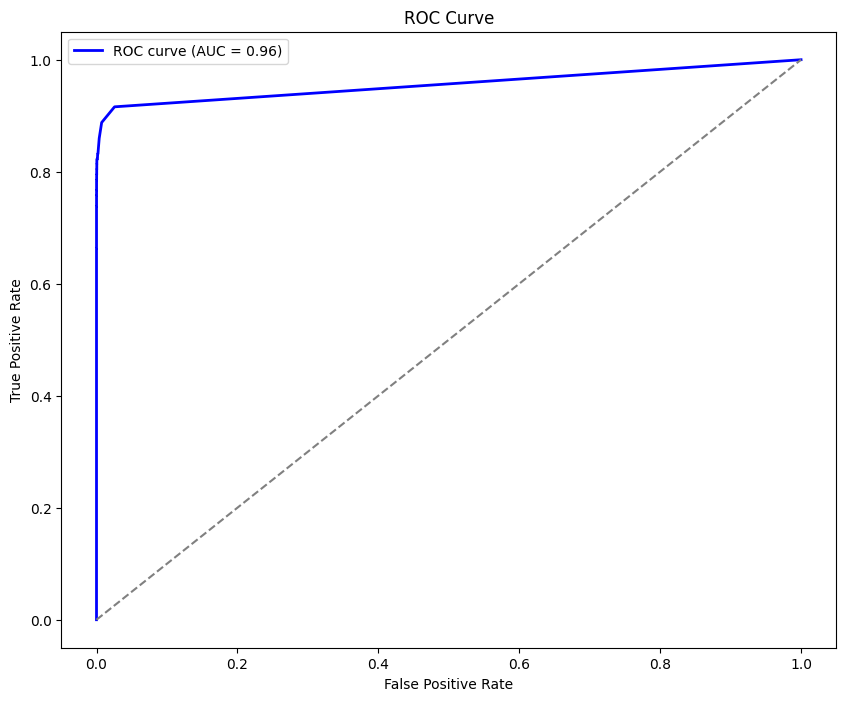

In [31]:
fpr, tpr, thresholds = roc_curve(y_test, preds)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(10, 8))
plt.plot(fpr,tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.title('ROC Curve')
plt.show()

## From what we know ROC curves above the diagonal are really good classifiers and the closer we are to an AUC of 1 is so better.

Try best Subset Selection 

In [84]:
subset_selection = []
val_accuracy = []
remain_feature = list(df.columns.drop('Class'))
best_val_accuracy = 0
n = len(remain_feature)
print(remain_feature)
for i in range(n):
    vals = {}
    for feature in remain_feature:
        subset = subset_selection.copy() + [feature]
        sub_x_train, sub_x_val, sub_y_train, sub_y_val = train_test_split(x_train[subset], y_train, test_size=.2, random_state=376)
        sub_train_df = sub_x_train.copy()
        sub_train_df['Class'] = sub_y_train.astype(int)  # ensure integer dtype
        sub_val_df = sub_x_val.copy()
        sub_val_df['Class'] = sub_y_val.astype(int)

        sub_train_ds = tfdf.keras.pd_dataframe_to_tf_dataset(sub_train_df, label="Class", task=tfdf.keras.Task.CLASSIFICATION)
        sub_val_ds = tfdf.keras.pd_dataframe_to_tf_dataset(sub_val_df, label="Class", task=tfdf.keras.Task.CLASSIFICATION)
        
        model_sub = tfdf.keras.RandomForestModel(verbose=2, task=tfdf.keras.Task.CLASSIFICATION, random_seed = 67)
        model_sub.fit(sub_train_ds)

        model_sub.compile(metrics=['accuracy'])
        evaluation = model_sub.evaluate(sub_val_ds, return_dict=True, use_multiprocessing=True)
        vals[feature] = evaluation['accuracy']
        
    best_sub_val = max(vals.values())
    best_feature = [key for key, item in vals.items() if item == best_sub_val][0]
    subset_selection.append(best_feature)
    val_accuracy.append(best_sub_val)
    remain_feature.remove(best_feature)
        
        
        


['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']
Use 12 thread(s) for training
Use /tmp/tmppycydyl_ as temporary training directory
Reading training dataset...
Training tensor examples:
Features: {'Time': <tf.Tensor 'data:0' shape=(None,) dtype=float64>}
Label: Tensor("data_1:0", shape=(None,), dtype=int64)
Weights: None
Normalized tensor features:
 {'Time': SemanticTensor(semantic=<Semantic.NUMERICAL: 1>, tensor=<tf.Tensor 'Cast:0' shape=(None,) dtype=float32>)}
Training dataset read in 0:00:00.207780. Found 182276 examples.
Training model...
Model trained in 0:00:03.953956
Compiling model...
Model compiled.
46/46 [==============================] - 1s 13ms/step - loss: 0.0000e+00 - accuracy: 0.9983
Use 12 thread(s) for training
Use /tmp/tmp5lrkigsq as temporary training directory
Reading training dataset...
Training tensor example

In [123]:
print(val_accuracy)
print(subset_selection)

[0.9990124702453613, 0.9993197321891785, 0.99942946434021, 0.999495267868042, 0.9995830655097961, 0.9995830655097961, 0.9996050000190735, 0.9996050000190735, 0.9996050000190735, 0.9996050000190735, 0.9995830655097961, 0.9995830655097961, 0.9995830655097961, 0.9995830655097961, 0.9995830655097961, 0.9995830655097961, 0.9995830655097961, 0.9995830655097961, 0.9995830655097961, 0.9995611310005188, 0.9995391368865967, 0.9995611310005188, 0.9995391368865967, 0.9995391368865967, 0.9995830655097961, 0.9995391368865967, 0.9995391368865967, 0.9995391368865967, 0.9995172023773193, 0.9995172023773193]
['V12', 'V17', 'V4', 'V14', 'V10', 'V6', 'Time', 'V5', 'V2', 'V3', 'V8', 'V11', 'V20', 'V25', 'V16', 'V27', 'V13', 'V28', 'V15', 'V24', 'V7', 'V18', 'V1', 'Amount', 'V22', 'V19', 'V21', 'V23', 'V9', 'V26']


Use 12 thread(s) for training
Use /tmp/tmpodk8sl8p as temporary training directory
Reading training dataset...
Training tensor examples:
Features: {'V12': <tf.Tensor 'data:0' shape=(None,) dtype=float64>, 'V17': <tf.Tensor 'data_1:0' shape=(None,) dtype=float64>, 'V4': <tf.Tensor 'data_2:0' shape=(None,) dtype=float64>, 'V14': <tf.Tensor 'data_3:0' shape=(None,) dtype=float64>, 'V10': <tf.Tensor 'data_4:0' shape=(None,) dtype=float64>, 'V6': <tf.Tensor 'data_5:0' shape=(None,) dtype=float64>, 'Time': <tf.Tensor 'data_6:0' shape=(None,) dtype=float64>}
Label: Tensor("data_7:0", shape=(None,), dtype=int64)
Weights: None
Normalized tensor features:
 {'V12': SemanticTensor(semantic=<Semantic.NUMERICAL: 1>, tensor=<tf.Tensor 'Cast:0' shape=(None,) dtype=float32>), 'V17': SemanticTensor(semantic=<Semantic.NUMERICAL: 1>, tensor=<tf.Tensor 'Cast_1:0' shape=(None,) dtype=float32>), 'V4': SemanticTensor(semantic=<Semantic.NUMERICAL: 1>, tensor=<tf.Tensor 'Cast_2:0' shape=(None,) dtype=float32>),

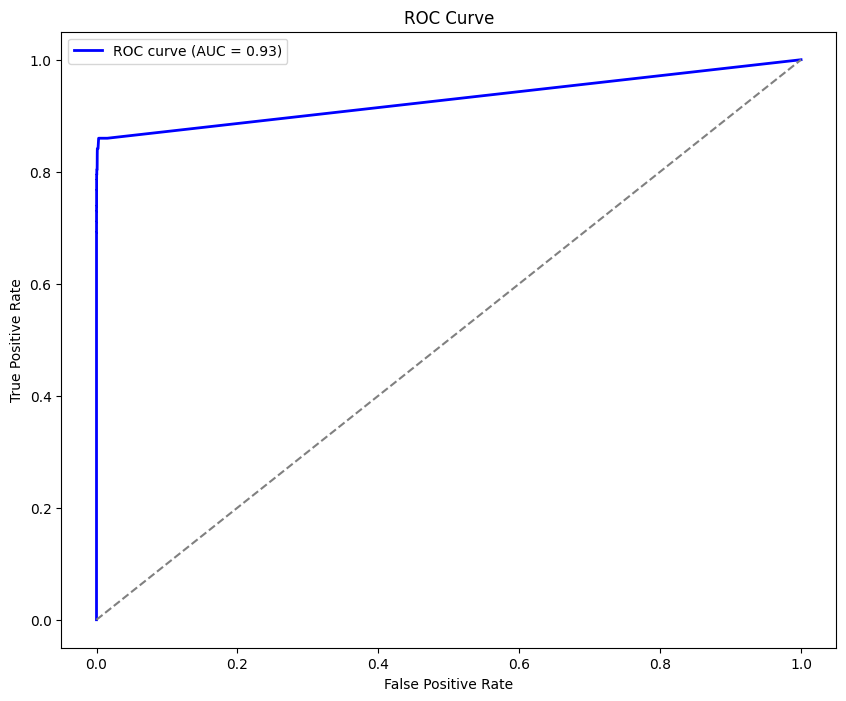

In [25]:
# So WE dont have to rerun the module above it took close to an hour the last time it was ran
subset_selection = ['V12', 'V17', 'V4', 'V14', 'V10', 'V6', 'Time', 'V5', 'V2', 'V3', 'V8', 'V11', 'V20', 'V25', 'V16', 'V27', 'V13', 'V28', 'V15', 'V24', 'V7', 'V18', 'V1', 'Amount', 'V22', 'V19', 'V21', 'V23', 'V9', 'V26']
subList = subset_selection[0:7]
one_x_train = x_train[subList].copy()
one_x_test = x_test[subList].copy()
one_x_train['Class'] = y_train.astype(int)
one_x_test['Class'] = y_test.astype(int)

one_train_ds = tfdf.keras.pd_dataframe_to_tf_dataset(one_x_train, label="Class", task=tfdf.keras.Task.CLASSIFICATION)
one_test_ds = tfdf.keras.pd_dataframe_to_tf_dataset(one_x_test, label="Class", task=tfdf.keras.Task.CLASSIFICATION)

model_1 = tfdf.keras.RandomForestModel(verbose=2, task=tfdf.keras.Task.CLASSIFICATION, random_seed = 67)
model_1.fit(one_train_ds)

preds_1 = model_1.predict(one_test_ds)

model_1.compile(metrics=['accuracy'])
evaluation = model_1.evaluate(one_test_ds, return_dict=True, use_multiprocessing=True)
print(evaluation)

fpr, tpr, thresholds = roc_curve(y_test, preds_1)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(10, 8))
plt.plot(fpr,tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.title('ROC Curve')
plt.show()


## Try Gradient Boosted Trees

In [22]:
model_gradient = tfdf.keras.GradientBoostedTreesModel(task=tfdf.keras.Task.CLASSIFICATION, verbose=2, random_seed = 67)
model_gradient.fit(train_ds)

Use 12 thread(s) for training
Use /tmp/tmpoj9u3dob as temporary training directory
Reading training dataset...


W0000 00:00:1765226298.051011     866 gradient_boosted_trees.cc:1873] "goss_alpha" set but "sampling_method" not equal to "GOSS".
W0000 00:00:1765226298.051044     866 gradient_boosted_trees.cc:1883] "goss_beta" set but "sampling_method" not equal to "GOSS".
W0000 00:00:1765226298.051047     866 gradient_boosted_trees.cc:1897] "selective_gradient_boosting_ratio" set but "sampling_method" not equal to "SELGB".


Training tensor examples:
Features: {'Time': <tf.Tensor 'data:0' shape=(None,) dtype=float64>, 'V1': <tf.Tensor 'data_1:0' shape=(None,) dtype=float64>, 'V2': <tf.Tensor 'data_2:0' shape=(None,) dtype=float64>, 'V3': <tf.Tensor 'data_3:0' shape=(None,) dtype=float64>, 'V4': <tf.Tensor 'data_4:0' shape=(None,) dtype=float64>, 'V5': <tf.Tensor 'data_5:0' shape=(None,) dtype=float64>, 'V6': <tf.Tensor 'data_6:0' shape=(None,) dtype=float64>, 'V7': <tf.Tensor 'data_7:0' shape=(None,) dtype=float64>, 'V8': <tf.Tensor 'data_8:0' shape=(None,) dtype=float64>, 'V9': <tf.Tensor 'data_9:0' shape=(None,) dtype=float64>, 'V10': <tf.Tensor 'data_10:0' shape=(None,) dtype=float64>, 'V11': <tf.Tensor 'data_11:0' shape=(None,) dtype=float64>, 'V12': <tf.Tensor 'data_12:0' shape=(None,) dtype=float64>, 'V13': <tf.Tensor 'data_13:0' shape=(None,) dtype=float64>, 'V14': <tf.Tensor 'data_14:0' shape=(None,) dtype=float64>, 'V15': <tf.Tensor 'data_15:0' shape=(None,) dtype=float64>, 'V16': <tf.Tensor 'data

Model: "gradient_boosted_trees_model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
Total params: 1 (1.00 Byte)
Trainable params: 0 (0.00 Byte)
Non-trainable params: 1 (1.00 Byte)
_________________________________________________________________
Type: "GRADIENT_BOOSTED_TREES"
Task: CLASSIFICATION
Label: "__LABEL"

Input Features (30):
	Amount
	Time
	V1
	V10
	V11
	V12
	V13
	V14
	V15
	V16
	V17
	V18
	V19
	V2
	V20
	V21
	V22
	V23
	V24
	V25
	V26
	V27
	V28
	V3
	V4
	V5
	V6
	V7
	V8
	V9

No weights

Variable Importance: INV_MEAN_MIN_DEPTH:
    1.    "V17"  0.357483 ################
    2.    "V14"  0.250064 ######
    3.     "V4"  0.203753 ##
    4.    "V20"  0.198153 #
    5.     "V8"  0.197017 #
    6.     "V2"  0.194393 #
    7.     "V7"  0.191819 #
    8. "Amount"  0.191044 
    9.    "V15"  0.190598 
   10.    "V16"  0.190463 
   11.    "V26"  0.190301 
   12.     "V1"  0.190240 
   13.    "V19"  0.18944

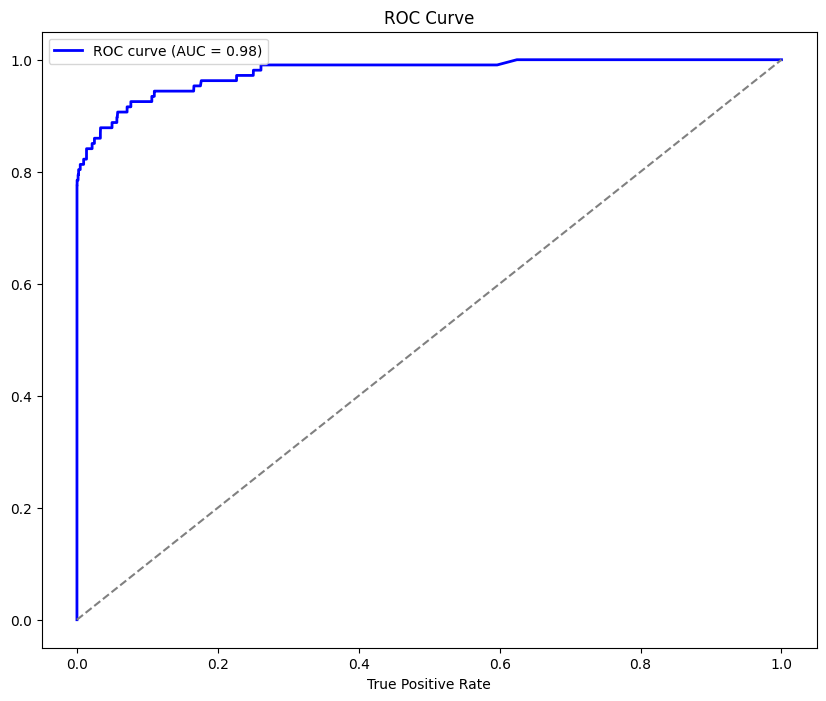

In [23]:
model_gradient.summary()
model_gradient.compile(metrics=['accuracy'])
evaluation = model_gradient.evaluate(test_ds, return_dict=True, use_multiprocessing=True)
preds = model_gradient.predict(test_ds)

print(f"The RMSE of this testing evaluation is: {evaluation}")

inspector = model_gradient.make_inspector()
print(inspector.evaluation())
print(inspector.variable_importances())
fpr, tpr, thresholds = roc_curve(y_test, preds)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(10, 8))
plt.plot(fpr,tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.xlabel('True Positive Rate')
plt.legend()
plt.title('ROC Curve')
plt.show()

Now use the subset up to Time that we found

In [21]:
model_gradient = tfdf.keras.GradientBoostedTreesModel(task=tfdf.keras.Task.CLASSIFICATION, verbose=2, random_seed = 67)
model_gradient.fit(one_train_ds)

model_gradient.summary()
model_gradient.compile(metrics=['accuracy'])
evaluation = model_gradient.evaluate(test_ds, return_dict=True, use_multiprocessing=True)
preds = model_gradient.predict(one_test_ds)


print(f"The RMSE of this testing evaluation is: {evaluation}")

inspector = model_gradient.make_inspector()
print(inspector.evaluation())
print(inspector.variable_importances())
fpr, tpr, thresholds = roc_curve(y_test, preds)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(10, 8))
plt.plot(fpr,tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.title('ROC Curve')
plt.show()

Use 12 thread(s) for training
Use /tmp/tmphvpxsw0f as temporary training directory


W0000 00:00:1765226287.744802     866 gradient_boosted_trees.cc:1873] "goss_alpha" set but "sampling_method" not equal to "GOSS".
W0000 00:00:1765226287.745216     866 gradient_boosted_trees.cc:1883] "goss_beta" set but "sampling_method" not equal to "GOSS".
W0000 00:00:1765226287.745220     866 gradient_boosted_trees.cc:1897] "selective_gradient_boosting_ratio" set but "sampling_method" not equal to "SELGB".


NameError: name 'one_train_ds' is not defined

## This already as a 99.94% accuracy for the testing data. We can try a logistic regression to compare using all predictors.

Train Accuracy: 0.9988720402027694
Test Accuracy: 0.9988588883817282


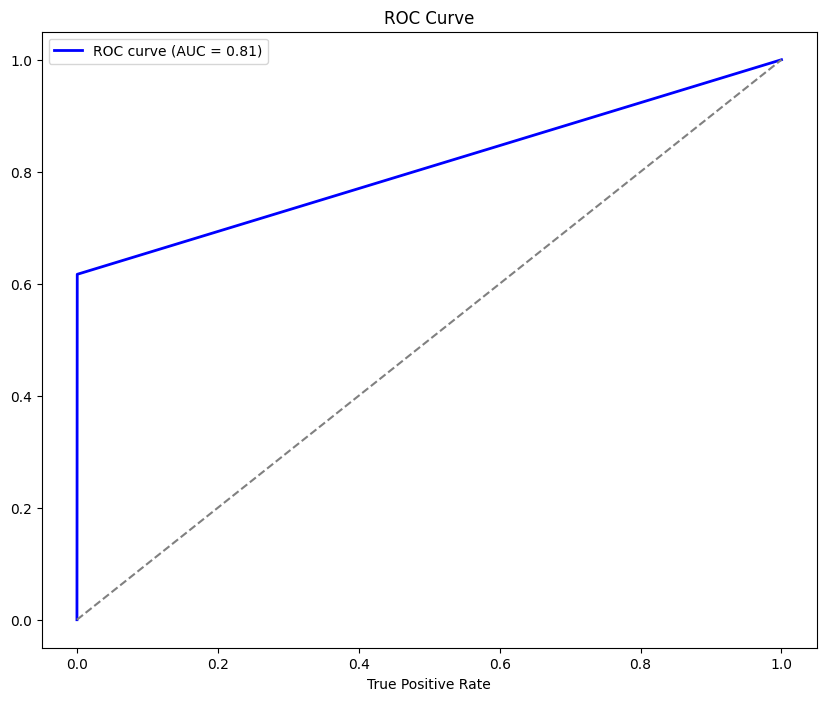

In [ ]:
logisticFit = LogisticRegression(solver="liblinear", penalty="l2", random_state=67)
logisticFit.fit(x_train.drop(columns=["Class"]), y_train)

pred_train = logisticFit.predict(x_train.drop(columns=["Class"]))
pred_test = logisticFit.predict(x_test.drop(columns=["Class"]))

pred_train_score = accuracy_score(y_train, pred_train)
pred_test_score = accuracy_score(y_test, pred_test)

print(f"Train Accuracy: {pred_train_score}")
print(f"Test Accuracy: {pred_test_score}")

fpr, tpr, thresholds = roc_curve(y_test, pred_test)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(10, 8))
plt.plot(fpr,tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.title('ROC Curve')
plt.show()

Try To find the best subset when using logistic regression

In [14]:
subset_selection_log = []
val_accuracy_log = []
remain_feature_log = list(df.columns.drop('Class'))
best_val_accuracy_log = 0
n = len(remain_feature_log)
print(remain_feature_log)
a = 0
for i in range(n):
    print(a)
    vals = {}
    for feature in remain_feature_log:
        subset = subset_selection_log.copy() + [feature]
        sub_x_train, sub_x_val, sub_y_train, sub_y_val = train_test_split(x_train[subset], y_train, test_size=.2, random_state=376)
        

        logisticFit = LogisticRegression(solver="liblinear", penalty="l2", random_state=67)
        logisticFit.fit(sub_x_train, sub_y_train)


        pred_test = logisticFit.predict(sub_x_val)


        vals[feature] = accuracy_score(sub_y_val, pred_test)
        
    best_sub_val = max(vals.values())
    best_feature = [key for key, item in vals.items() if item == best_sub_val][0]
    subset_selection_log.append(best_feature)
    val_accuracy_log.append(best_sub_val)
    remain_feature_log.remove(best_feature)
    a = a +1

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29


In [15]:
print(subset_selection_log)
print(val_accuracy_log)

['V14', 'V12', 'V4', 'V22', 'V1', 'V16', 'V3', 'V10', 'V13', 'V11', 'V17', 'V15', 'V18', 'V19', 'V23', 'V21', 'V26', 'V9', 'V6', 'V24', 'V25', 'V27', 'V28', 'Amount', 'V7', 'V2', 'V8', 'V5', 'V20', 'Time']
[0.9987491496412034, 0.999100265531392, 0.9991441550176655, 0.9991660997608023, 0.9991660997608023, 0.999188044503939, 0.999188044503939, 0.9992099892470758, 0.9992319339902126, 0.9992538787333495, 0.9992758234764862, 0.9992758234764862, 0.9992758234764862, 0.9992758234764862, 0.9992758234764862, 0.9992758234764862, 0.999297768219623, 0.9992758234764862, 0.9992758234764862, 0.9992538787333495, 0.9992099892470758, 0.999188044503939, 0.999188044503939, 0.999188044503939, 0.9991660997608023, 0.9991222102745287, 0.9991660997608023, 0.9991660997608023, 0.9991441550176655, 0.9989027628431609]


Use first 7 of subset the same as the one found for the Random Forest

Test Accuracy: 0.9991573329588147


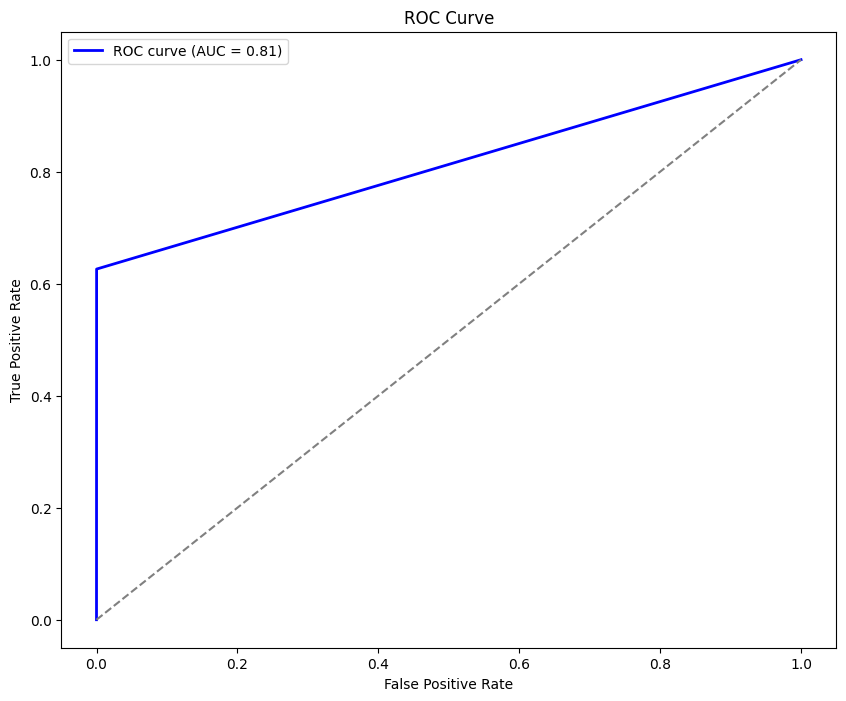

In [20]:
subset_log = subset_selection_log[0:7]
one_x_train_log = x_train[subset_log].copy()
one_x_test_log = x_test[subset_log].copy()


model_subset_log = LogisticRegression(solver="liblinear", penalty="l2", random_state=67)
model_subset_log.fit(one_x_train_log, y_train)


pred_test_log = model_subset_log.predict(one_x_test_log)
pred_test_score = accuracy_score(y_test, pred_test_log)
print(f"Test Accuracy: {pred_test_score}")
fpr, tpr, thresholds = roc_curve(y_test, pred_test_log)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(10, 8))
plt.plot(fpr,tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.title('ROC Curve')
plt.show()